此文件是用来调查为什么异构储层的CQ值要低于uniform储层，即便在相同超参数搜索空间下。

chatgpt给出的意见：由于权重均一化，对于相同的输入，异构储层transform后的信号强度要小于均匀储层的。这导致了KR和GR统计超过阈值的奇异值数量偏低。

In [1]:
import os
import torch 
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import tqdm as tqdm
import pickle

from pathlib import Path

CANDIDATES = [
    Path(r"C:\Users\tom\Desktop\Repository"),
    Path(r"C:\Users\Chen\Desktop\Repository"),
]
searchpaths = [p for p in CANDIDATES if p.exists()]

#tuple of repos
repos = ('machine_learning_library',)

import sys
import os
# In Jupyter notebooks, __file__ is not defined. Use the current working directory instead.
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import repo_tools
repo_tools.repos_path_finder(searchpaths, repos)
from spnc import spnc_anisotropy
import spnc_ml as ml
from deterministic_mask import fixed_seed_mask, max_sequences_mask

from single_node_res import single_node_reservoir
import ridge_regression as RR
from linear_layer import *
from mask import binary_mask
from utility import *
from NARMA10 import NARMA10
from datasets.load_TI46_digits import *
import datasets.load_TI46 as TI46
from sklearn.metrics import classification_report
from formal_Parameter_Dynamics_Preformance import *

from Morphology_Research.Reservoirs_morphology_creator import MorphologyConfig, ReservoirMorphologyManager
from Morphology_Research.Reservoirs_morphology_evaluation import *

In [3]:
def RunSpnc(signal,Nin,Nout,Nvirt,m0,transform, params,**kwargs):
    '''
    Run a reservoir computer with the signal sequence
    '''
    snr = single_node_reservoir(Nin, Nout, Nvirt, m0, res=transform)

    fixed_mask = kwargs.get('fixed_mask', False)
    if fixed_mask==True:
        # print("Deterministic mask will be used")
        seed_mask = kwargs.get('seed_mask', 1234)
        if seed_mask>=0:
            # print(seed_mask)
            snr.M = fixed_seed_mask(Nin, Nvirt, m0, seed=seed_mask)
        else:
            # print("Max_sequences mask will be used")
            snr.M = max_sequences_mask(Nin, Nvirt, m0)
    
    # Run
    S,_ = snr.transform(signal,params)
    
    return S

In [17]:
def RunSpnc_omegacons(signal,Nin,Nout,Nvirt,m0,transform, params,beta_cons,**kwargs):
    '''
    Run a reservoir computer with the signal sequence
    '''
    snr = single_node_reservoir(Nin, Nout, Nvirt, m0, res=transform)

    fixed_mask = kwargs.get('fixed_mask', False)
    if fixed_mask==True:
        # print("Deterministic mask will be used")
        seed_mask = kwargs.get('seed_mask', 1234)
        if seed_mask>=0:
            # print(seed_mask)
            snr.M = fixed_seed_mask(Nin, Nvirt, m0, seed=seed_mask)
        else:
            # print("Max_sequences mask will be used")
            snr.M = max_sequences_mask(Nin, Nvirt, m0)
    
    # Run
    S,_ = snr.transform(signal,params,beta_cons)
    
    return S

In [33]:
def gen_KR_GR_input(Nreadouts, Nwash=10, seed=1234):
    # set seed
    np.random.seed(seed)
    # generate KR inputs
    KR_inputs = np.random.ranf((Nreadouts, Nwash))
    # 打印KR_inputs
    # print('KR_inputs',KR_inputs)
    # print('shape of KR_inputs',np.shape(KR_inputs))

    GR_inputs = np.tile(np.random.ranf((10)), (Nreadouts,1))
    # print('GR_inputs',GR_inputs)
    # print('shape of GR_inputs',np.shape(GR_inputs))

    all_inputs = np.concatenate((KR_inputs, GR_inputs), axis=1)
    # 打印all_inputs的前10个元素
    # print('all_inputs',all_inputs)
    # print('shape of all_inputs',np.shape(all_inputs))
    return all_inputs


def Evaluate_KR_GR(states, Nreadouts, threshold=0.1):
    GR_states = states[:,-1,:]
    # print('GR_states',GR_states)
    # print('shape of GR_states',np.shape(GR_states))
    '''
    Change the last 7 columns to GR states, the rest are KR states
    '''
    KR_states = states[:,-11,:]
    # print('KR_states',KR_states)
    # print('shape of KR_states',np.shape(KR_states)) 
    
    uGR, sGR, vGR = np.linalg.svd(GR_states)
    uKR, sKR, vKR = np.linalg.svd(KR_states)
    KR = 0
    GR = 0
    for i in range(Nreadouts):
        if sGR[i]>threshold:
            GR += 1
        if sKR[i]>threshold:
            KR += 1
    return KR, GR, GR_states, KR_states,sGR,sKR

def evaluate_KRandGR(reservoir_params, Nreadouts=50, Nwash=10, **kwargs):
    
    Nreadouts= reservoir_params.Nvirt

    inputs = gen_KR_GR_input(Nreadouts, Nwash, seed=1234)   # <--- 用Nreadouts
    outputs = []
    for input_row in inputs:
        input_row = input_row.reshape(-1, 1)
        spn = spnc_anisotropy(reservoir_params.h, reservoir_params.theta_H,
                              reservoir_params.k_s_0, reservoir_params.phi,
                              reservoir_params.beta_prime, restart=True)
        transforms = spn.gen_signal_slow_delayed_feedback
        output = RunSpnc(input_row, 1, 1, reservoir_params.Nvirt,
                         reservoir_params.m0, transforms, reservoir_params.params, fixed_mask=True, seed_mask=1234)
        outputs.append(output)
    States = np.stack(outputs, axis=0)
    Normalized_States = States/np.amax(States)
    use_normalized = kwargs.get('use_normalized', False)
    if use_normalized:
        States = Normalized_States
    else:
        States = States 
    KR, GR, GR_states, KR_states,sGR,sKR = Evaluate_KR_GR(States, Nreadouts, threshold=0.001)  # <--- 用Nreadouts
    return KR, GR, GR_states, KR_states,sGR,sKR, outputs, States, Normalized_States

# ------------------------ Reservoir ----------------------------


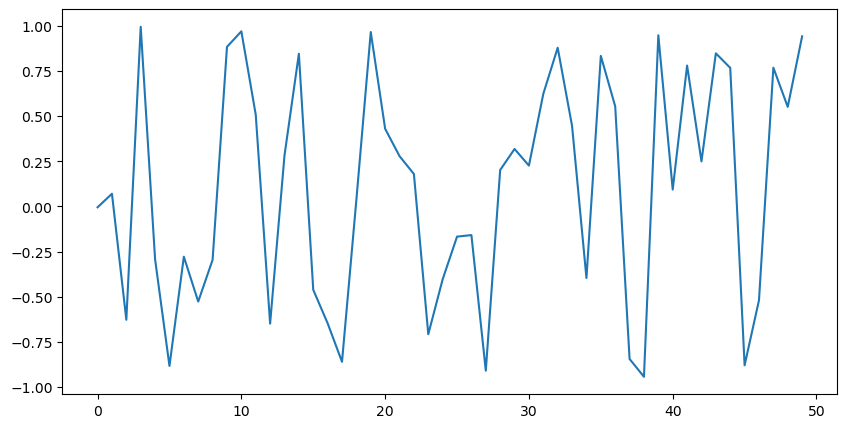

In [2]:
# 创建一个随机输出
noise_input = np.random.uniform(-1, 1, 500)

plt.figure(figsize=(10, 5))
plt.plot(noise_input[0:50])
plt.show()

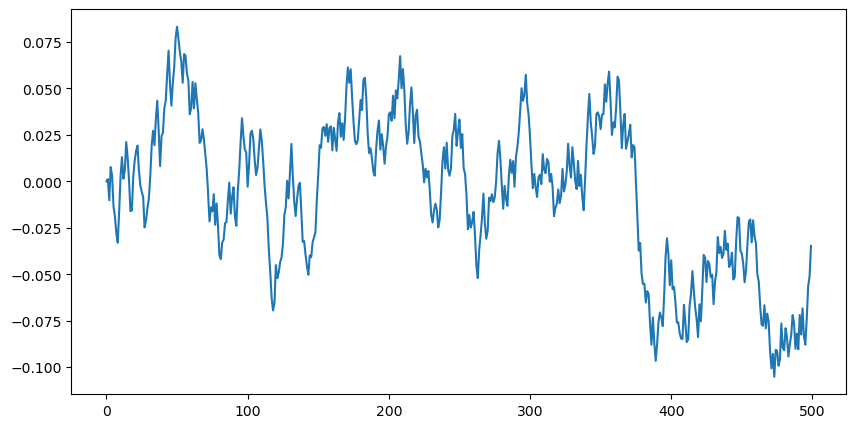

In [6]:
# 创建bestMC储层
spn_bestMC = spnc_anisotropy(0.4,90,0,45,50,restart=True)
params_bestMC = ReservoirParams(
        h=0.4, m0=0.008, Nvirt=1, beta_prime=	50.0,
        params={'theta': 0.1564938388583194, 'gamma': 0.04608425844940916, 'Nvirt': 1}
    )
transform_bestMC =  spn_bestMC.gen_signal_slow_delayed_feedback
S_bestMC = RunSpnc(noise_input.reshape(-1, 1), 1, 1, params_bestMC.Nvirt, params_bestMC.m0, transform_bestMC, params_bestMC.params, fixed_mask=True, seed_mask=1234)
plt.figure(figsize=(10, 5))
plt.plot(S_bestMC)
plt.show()



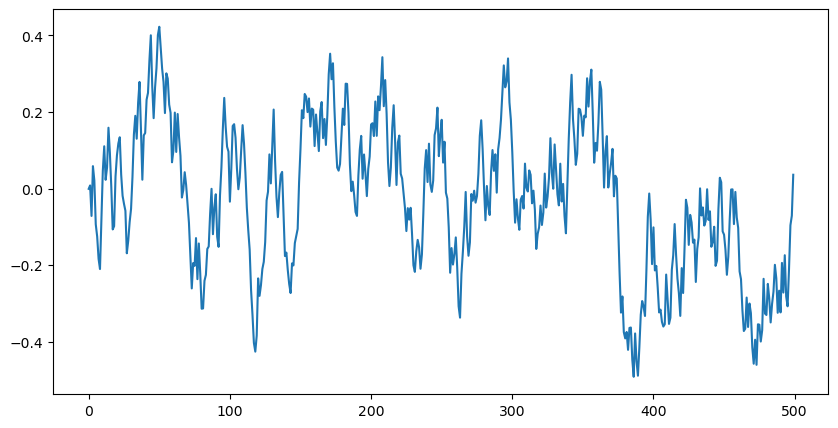

In [21]:
# 试试两个子储层
spn_sub1 = spnc_anisotropy(0.4,90,0,45,48.84054153413578,restart=True)
params_sub1 = ReservoirParams(
        h=0.4, m0=0.03050572421986144, Nvirt=1, beta_prime=	48.84054153413578,
        params={'theta': 0.2, 'gamma': 0.04776541460210942, 'Nvirt': 1}
    )
transform_sub1 =  spn_sub1.gen_signal_slow_delayed_feedback_omegacons
S_sub1 = RunSpnc_omegacons(noise_input.reshape(-1, 1), 1, 1, params_sub1.Nvirt, params_sub1.m0, transform_sub1, params_sub1.params,50, fixed_mask=True, seed_mask=1234)
plt.figure(figsize=(10, 5))
plt.plot(S_sub1)
plt.show()

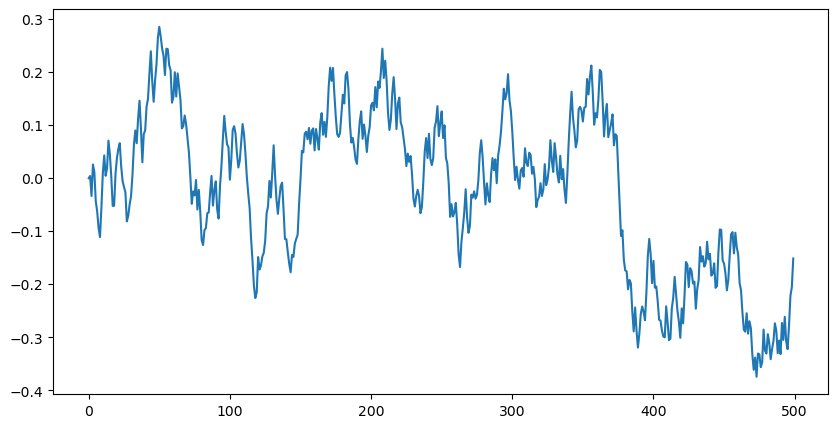

In [22]:
# 试试两个子储层
spn_sub2 = spnc_anisotropy(0.4,90,0,45,51.15945846586422,restart=True)
params_sub2 = ReservoirParams(
        h=0.4, m0=0.03050572421986144, Nvirt=1, beta_prime=	51.15945846586422,
        params={'theta': 0.2, 'gamma': 0.04776541460210942, 'Nvirt': 1}
    )
transform_sub2 =  spn_sub2.gen_signal_slow_delayed_feedback_omegacons
S_sub2 = RunSpnc_omegacons(noise_input.reshape(-1, 1), 1, 1, params_sub2.Nvirt, params_sub2.m0, transform_sub2, params_sub2.params,50, fixed_mask=True, seed_mask=1234)
plt.figure(figsize=(10, 5))
plt.plot(S_sub2)
plt.show()

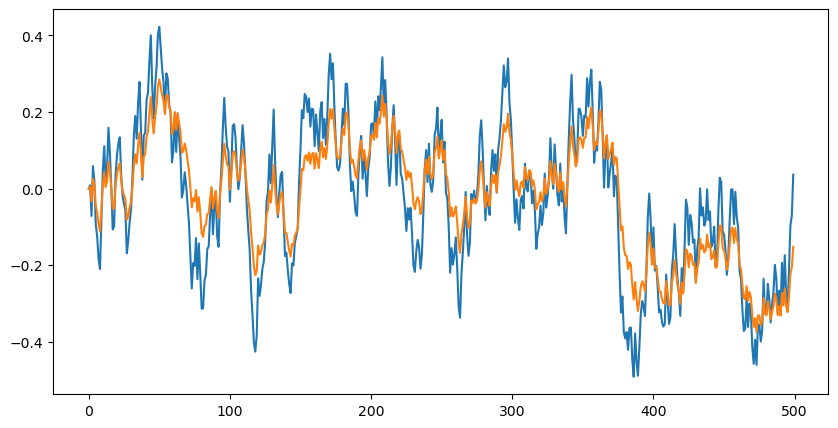

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(S_sub1)
plt.plot(S_sub2)
plt.show()

[0.11864238049494717, 0.8813576195050529]


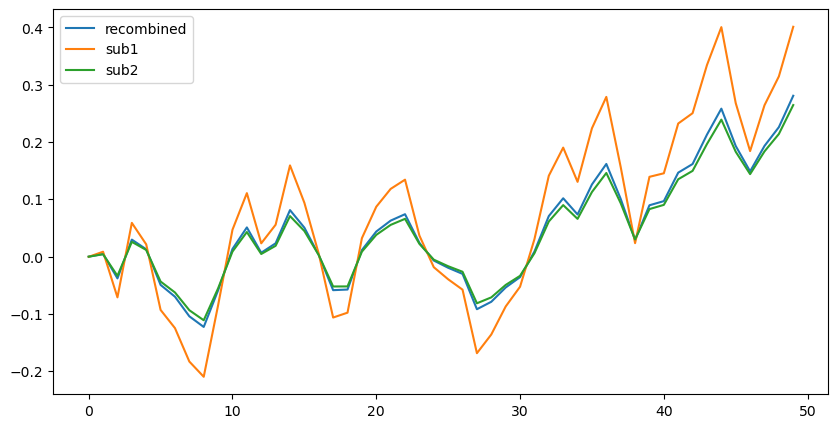

In [30]:
#尝试按照weights来重组信号
# weight1 = 0.126265013947872; weight2 = 0.9379838103013135

# 重新均一化
weights = [0.126265013947872, 0.9379838103013135]
weights = [w / sum(weights) for w in weights]

print(weights)

# 重组信号
S_recombined = weights[0] * S_sub1 + weights[1] * S_sub2

# 绘制重组信号
plt.figure(figsize=(10, 5))
plt.plot(S_recombined[0:50],label='recombined')
plt.plot(S_sub1[0:50],label='sub1')
plt.plot(S_sub2[0:50],label='sub2')
plt.legend()
plt.show()


In [38]:
bestMC = ReservoirParams(
        h=0.4, m0=0.008, Nvirt=200, beta_prime=	50.0,
        params={'theta': 0.1564938388583194, 'gamma': 0.04608425844940916, 'Nvirt': 200}
    )

sub1 = ReservoirParams(
        h=0.4, m0=0.03050572421986144, Nvirt=200, beta_prime=	48.84054153413578,
        params={'theta': 0.2, 'gamma': 0.04776541460210942, 'Nvirt': 200}
    )
sub2 = ReservoirParams(
        h=0.4, m0=0.03050572421986144, Nvirt=200, beta_prime=	51.15945846586422,
        params={'theta': 0.2, 'gamma': 0.04776541460210942, 'Nvirt': 200}
    )


In [39]:
# 看看sub1和sub2的CQ
KR_bestMC, GR_bestMC, GR_states_bestMC, KR_states_bestMC,sGR_bestMC,sKR_bestMC, outputs_bestMC, States_bestMC, Normalized_States_bestMC= evaluate_KRandGR(bestMC, threshold=0.001)
print('KR_bestMC, GR_bestMC', KR_bestMC, GR_bestMC)
print('#########################')

KR_sub1, GR_sub1, GR_states_sub1, KR_states_sub1,sGR_sub1,sKR_sub1, outputs_sub1, States_sub1, Normalized_States_sub1= evaluate_KRandGR(sub1, threshold=0.001)
print('KR_sub1, GR_sub1', KR_sub1, GR_sub1)
print('#########################')

KR_sub2, GR_sub2, GR_states_sub2, KR_states_sub2,sGR_sub2,sKR_sub2, outputs_sub2, States_sub2, Normalized_States_sub2= evaluate_KRandGR(sub2, threshold=0.001)
print('KR_sub2, GR_sub2', KR_sub2, GR_sub2)
print('#########################')


KR_bestMC, GR_bestMC 35 6
#########################
KR_sub1, GR_sub1 65 11
#########################
KR_sub2, GR_sub2 66 13
#########################


In [40]:
good = ReservoirParams(
        h=0.4, m0=0.03, Nvirt=200, beta_prime=	50,
        params={'theta': 0.2, 'gamma': 0.045, 'Nvirt': 200}
    )
KR_good, GR_good, GR_states_good, KR_states_good,sGR_good,sKR_good, outputs_good, States_good, Normalized_States_good= evaluate_KRandGR(good, threshold=0.001)
print('KR_good, GR_good', KR_good, GR_good)
print('#########################')

KR_good, GR_good 64 9
#########################
